# 03 — Evaluation

In diesem Notebook geht es um die Evaluation des finalen Modells 
`freshify_baseline_with_new_raw.keras` auf dem Validation Split `data/val/`. 
Es vergleicht das finale Modell mit älteren Modellständen sowie verschiedenen 
Trainingsexperimenten. Die Vergleichsexperimente testen mehr Augmentation in 
beide Richtungen, mehr Standard-Augmentation und mehr Background-Augmentation,um zu zeigen warum der finale Stand die beste Balance erreicht.

**Finales Modell:** `models/freshify_baseline_with_new_raw.keras`  
**Threshold:** `0.50`  
**Datensatz:** `data/val/`   62 Bilder (34 edible, 28 non_edible)

### Aufbau
1. Metriken & Interpretation
2. Confusion Matrix
3. Modell- & Threshold-Vergleich

In [13]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
import os
os.chdir("..")
from sklearn.metrics import (
    confusion_matrix, 
    ConfusionMatrixDisplay,
    roc_curve, 
    auc,
    precision_recall_fscore_support,
    classification_report
)

## 1. Metriken


Im Business-Kontext sind nicht alle Metriken gleich wichtig:

- **Recall `non_edible`** → wichtigste Metrik
- **False Negatives** → kritischster Fehler
- **False Positives** → akzeptabel, aber nicht zu viele
- **Accuracy & Precision** → gutes Gesamtbild

Die genaue Interpretation folgt direkt bei den jeweiligen Visualisierungen.

### Ergebnisse finales Modell:

Aus `reports/` laden wir die `evaluation.json` des finalen Modells.

In [14]:
report_path = Path("reports/freshify_baseline_with_new_raw_threshold_050/evaluation.json")

with open(report_path) as f:
    eval_data = json.load(f)

In [15]:
metrics = {
    "Accuracy":              eval_data["accuracy"],
    "Precision non_edible":  eval_data["precision_non_edible"],
    "Recall non_edible":     eval_data["recall_non_edible"],
    "False Negatives":       eval_data["false_negatives_non_edible"],
    "False Positives":       eval_data["false_positives_non_edible"],
}

df_metrics = pd.DataFrame(metrics.items(), columns=["Metrik", "Wert"])
df_metrics["Wert"] = df_metrics["Wert"].apply(
    lambda x: f"{x:.4f}" if isinstance(x, float) and x < 1 else int(x) if isinstance(x, float) else x
)
df_metrics

,Metrik,Wert
0,Accuracy,0.9032
1,Precision non_edible,0.8929
2,Recall non_edible,0.8929
3,False Negatives,3
4,False Positives,3


### Interpretation

Das finale Modell erreicht **90.32% Accuracy** auf dem Validation Split.

Für den Tafel-Kontext entscheidend:
- **Recall non_edible: 89.29%** — 25 von 28 verdorbenen Lebensmitteln korrekt erkannt
- **3 False Negatives** — verdorbene Lebensmittel die als essbar durchgelassen wurden → kritischster Fehler

Weitere relevante Metriken:
- **3 False Positives** — essbare Lebensmittel unnötig markiert → durch Human-Review abgefangen
- **Recall edible: 91.18%** — 31 von 34 essbaren Lebensmitteln korrekt erkannt
- **True Positives: 25, True Negatives: 31** — Gesamtbild der korrekten Klassifikationen

## 2. Confusion Matrix

Die Confusion Matrix zeigt wie das Modell die 62 Validierungsbilder klassifiziert hat — 
aufgeteilt in korrekte und falsche Vorhersagen.

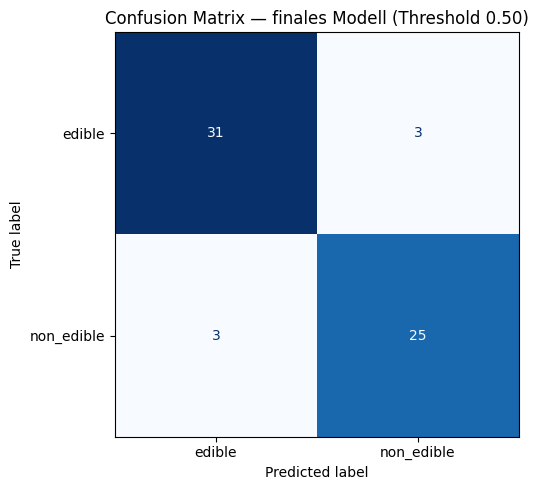

In [16]:
cm = eval_data["confusion_matrix"]

matrix = np.array([
    [cm["true_negative_edible"],   cm["false_positive_non_edible"]],
    [cm["false_negative_non_edible"], cm["true_positive_non_edible"]]
])

disp = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=["edible", "non_edible"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — finales Modell (Threshold 0.50)")
plt.tight_layout()
plt.show()

Die Confusion Matrix zeigt die vier möglichen Klassifikationsergebnisse:

- **True Negative (31)** — essbare Lebensmittel korrekt als edible erkannt
- **True Positive (25)** — verdorbene Lebensmittel korrekt als non_edible erkannt
- **False Negative (3)** — verdorbene Lebensmittel fälschlicherweise als edible durchgelassen → kritisch
- **False Positive (3)** — essbare Lebensmittel fälschlicherweise als non_edible markiert → durch Human-Review abgefangen

## 3. Modell- & Threshold-Vergleich

In diesem Abschnitt vergleichen wir die vorhandenen `evaluation.json` Reports aus `reports/`. Relevant sind vor allem Vergleiche auf demselben Validation Split, weil nur dort Accuracy, Recall und Fehlerzahlen direkt vergleichbar sind. Der Fokus liegt auf `Recall non_edible` und False Negatives, weil ein übersehenes verdorbenes Lebensmittel im Business-Kontext kritischer ist als ein zusätzlicher Human-Review-Fall.

In [19]:
evaluation_paths = sorted(Path("reports").rglob("evaluation.json"))

model_name_map = {
    "freshify_baseline_after_data_cleanup": "baseline after data cleanup",
    "freshify_baseline_with_new_raw": "baseline with new_raw",
}

rows = []
for path in evaluation_paths:
    report_dir = path.parent
    name = report_dir.name

    if "threshold_" not in name:
        continue  # nur Reports mit Threshold im Namen zählen

    model_key, threshold_str = name.rsplit("_threshold_", 1)
    if model_key not in model_name_map:
        continue  # nur die zwei relevanten Modelle

    with open(path) as f:
        data = json.load(f)

    rows.append({
        "Modell": model_name_map[model_key],
        "Threshold": int(threshold_str) / 100,
        "Accuracy": data["accuracy"],
        "Recall non_edible": data["recall_non_edible"],
        "False Negatives": data["false_negatives_non_edible"],
        "False Positives": data["false_positives_non_edible"],
    })

df_model_threshold_comparison = (
    pd.DataFrame(rows)
    .sort_values(["Modell", "Threshold"])
    .reset_index(drop=True)
)

df_model_threshold_comparison.style.format({
    "Threshold": "{:.2f}",
    "Accuracy": "{:.4f}",
    "Recall non_edible": "{:.4f}",
})

,Modell,Threshold,Accuracy,Recall non_edible,False Negatives,False Positives
0,baseline after data cleanup,0.35,0.7097,0.9286,2,16
1,baseline after data cleanup,0.40,0.7419,0.9286,2,14
2,baseline after data cleanup,0.45,0.7742,0.9286,2,12
3,baseline after data cleanup,0.50,0.8065,0.8929,3,9
4,baseline with new_raw,0.35,0.7903,0.8929,3,10
5,baseline with new_raw,0.45,0.8871,0.8929,3,4
6,baseline with new_raw,0.50,0.9032,0.8929,3,3


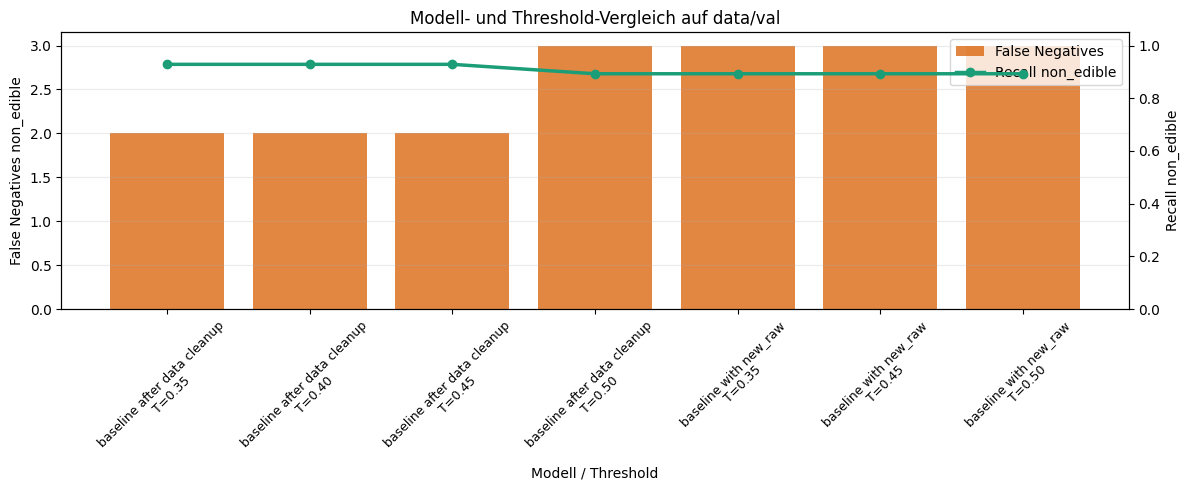

In [22]:
plot_df = df_model_threshold_comparison.copy()
plot_df["Run"] = plot_df["Modell"] + "\nT=" + plot_df["Threshold"].map(lambda x: f"{x:.2f}")

fig, ax_fn = plt.subplots(figsize=(12, 5))

ax_fn.bar(
    plot_df["Run"],
    plot_df["False Negatives"],
    color="#d95f02",
    alpha=0.75,
    label="False Negatives"
)
ax_fn.set_ylabel("False Negatives non_edible")
ax_fn.set_xlabel("Modell / Threshold")
ax_fn.tick_params(axis="x", rotation=45, labelsize=9)
ax_fn.grid(axis="y", alpha=0.25)

ax_recall = ax_fn.twinx()
ax_recall.plot(
    plot_df["Run"],
    plot_df["Recall non_edible"],
    color="#1b9e77",
    marker="o",
    linewidth=2.5,
    label="Recall non_edible"
)
ax_recall.set_ylabel("Recall non_edible")
ax_recall.set_ylim(0, 1.05)

lines_1, labels_1 = ax_fn.get_legend_handles_labels()
lines_2, labels_2 = ax_recall.get_legend_handles_labels()
ax_fn.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

ax_fn.set_title("Modell- und Threshold-Vergleich auf data/val")
plt.tight_layout()
plt.show()

### Interpretation

Der beste aktuelle Kompromiss ist `baseline with new_raw` bei Threshold `0.50`. 
Dieses Modell erreicht auf `data/val` die höchste Accuracy (`90.32%`) und hält 
den `Recall non_edible` bei `89.29%`. Die False Negatives bleiben bei `3`, also 
auf dem Niveau der stärkeren alten Modelle.

Der entscheidende Unterschied liegt bei den False Positives: `old final demo` 
hatte bei gleichem `non_edible` Recall `12` False Positives, `old background 
augmentation` hatte `6`, die finale Baseline mit `new_raw` bei Threshold `0.50` 
nur `3`. Damit werden weiterhin viele verdorbene Lebensmittel erkannt, aber 
deutlich weniger essbare Lebensmittel unnötig in den Human Review geschickt.

Niedrigere Thresholds erhöhen nicht automatisch die beste Praxisqualität. Beim 
Modell `baseline after data cleanup` steigt der `non_edible` Recall bei `0.35` 
bis `0.45` auf `92.86%`, aber die False Positives steigen stark auf `12` bis `16`. 
Für den Tafel-Workflow wäre das sehr vorsichtig, aber ineffizient.

`baseline with new_raw` enthält zusätzlich gezielte Datenauffüllung schwacher 
Kategorien sowie einige neue eigene Smartphonebilder, was das Modell 
wahrscheinlich robuster auf echten Fotos macht. Threshold `0.50` liefert deshalb 
aktuell die beste Balance aus hoher Gesamtleistung, stabilem `non_edible` Recall 
und wenigen unnötigen Review-Fällen.

**Wichtige Einschränkung:** Die früheren `new_raw` Bilder sind inzwischen Teil 
von `train`. Für eine echte Real-World-Aussage braucht es einen neuen 
unabhängigen Holdout mit `edible` und `non_edible` Bildern.